# Notebook 01 — Data exploration and preparation

This notebook performs the first step of the ACT209 pricing frequency project.

The objective is to:

1. load the raw motor insurance frequency dataset;
2. check the actuarial validity of the target variables;
3. create the empirical claim frequency target;
4. perform basic exploratory data analysis;
5. save a clean processed dataset for the modeling notebooks.

The modeling step is not performed in this notebook. It is handled later in:

- `02_modeling_glm_gb.ipynb`;
- `03_final_results.ipynb`.

## Actuarial setup

For each policy \(i\), we use the following notation:

\[
N_i = \text{observed claim count},
\]

\[
E_i = \text{exposure},
\]

\[
Y_i^{freq} = \frac{N_i}{E_i}.
\]

The empirical claim frequency is therefore defined as:

\[
\text{claim\_frequency}_i = \frac{\text{ClaimNb}_i}{\text{Exposure}_i}.
\]

In the modeling notebooks, the models will predict annual claim frequency \(\widehat{\lambda}_i\), and the expected claim count will be reconstructed as:

\[
\widehat{\mu}_i = E_i \widehat{\lambda}_i.
\]

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW_PATH = PROJECT_ROOT / "data" / "raw" / "freMTPL2freq.csv"
DATA_PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "frequency_clean.csv"

OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('c:/Users/hoxhi/Desktop/act209_pricing_frequency')

In [4]:
from src.data_preparation import (
    load_raw_data,
    summarize_data_quality,
    clean_frequency_data,
    get_feature_columns,
    split_numeric_categorical_features,
    save_processed_data,
)

## 1. Load raw data

We first load the raw motor insurance frequency dataset from:

```text
data/raw/freMTPL2freq.csv
```

In [5]:
df_raw = load_raw_data(DATA_RAW_PATH)

df_raw.shape

(678013, 12)

In [7]:
df_raw.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine


In [8]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   VehPower    678013 non-null  int64  
 4   VehAge      678013 non-null  int64  
 5   DrivAge     678013 non-null  int64  
 6   BonusMalus  678013 non-null  int64  
 7   VehBrand    678013 non-null  str    
 8   VehGas      678013 non-null  str    
 9   Area        678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 62.1 MB


In [9]:
df_raw.columns.tolist()

['IDpol',
 'ClaimNb',
 'Exposure',
 'VehPower',
 'VehAge',
 'DrivAge',
 'BonusMalus',
 'VehBrand',
 'VehGas',
 'Area',
 'Density',
 'Region']

## 2. Data quality checks

The main actuarial target variables are:

- `ClaimNb`: observed claim count;
- `Exposure`: policy exposure.

For frequency modeling, the key validity constraints are:

\[
\text{Exposure} > 0,
\]

\[
\text{ClaimNb} \geq 0.
\]

We also check missing values and compute the global observed annual claim frequency:

\[
\frac{\sum_i N_i}{\sum_i E_i}.
\]

In [10]:
data_quality_summary = summarize_data_quality(df_raw)

data_quality_summary

{'n_rows': 678013,
 'n_columns': 12,
 'missing_claim_count': 0,
 'missing_exposure': 0,
 'exposure_leq_zero': 0,
 'claim_count_negative': 0,
 'total_claim_count': 36102.0,
 'total_exposure': 358499.44546217704,
 'global_claim_frequency': 0.10070308464063966}

In [11]:
data_quality_table = pd.DataFrame(
    data_quality_summary.items(),
    columns=["metric", "value"],
)

data_quality_table

,metric,value
0,n_rows,678013.000000
1,n_columns,12.000000
2,missing_claim_count,0.000000
3,missing_exposure,0.000000
4,exposure_leq_zero,0.000000
5,claim_count_negative,0.000000
6,total_claim_count,36102.000000
7,total_exposure,358499.445462
8,global_claim_frequency,0.100703


## 3. Create clean frequency dataset

The cleaned dataset is created using the project function `clean_frequency_data`.

This function:

1. removes invalid observations for the core actuarial constraints;
2. verifies that exposures are strictly positive;
3. verifies that claim counts are non-negative;
4. creates the empirical frequency target:

\[
\text{claim\_frequency}_i = \frac{\text{ClaimNb}_i}{\text{Exposure}_i}.
\]

No imputation, encoding or scaling is performed at this stage. Those operations are handled later inside scikit-learn preprocessing pipelines to avoid data leakage.

In [12]:
df_clean = clean_frequency_data(df_raw)

df_clean.shape

(678013, 13)

In [13]:
df_clean.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,claim_frequency
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,10.000000
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,1.298701
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,1.333333
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,11.111111
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,1.190476


In [14]:
df_clean[["ClaimNb", "Exposure", "claim_frequency"]].head()

,ClaimNb,Exposure,claim_frequency
0,1,0.10,10.000000
1,1,0.77,1.298701
2,1,0.75,1.333333
3,1,0.09,11.111111
4,1,0.84,1.190476


In [15]:
df_clean["claim_frequency"].describe()

count    678013.000000
mean          0.263964
std           4.593916
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         732.000117
Name: claim_frequency, dtype: float64

## 4. Exploratory data analysis

We perform a small number of descriptive analyses to understand the structure of the portfolio before modeling.

The purpose is not to optimize a model here, but to check the empirical distribution of:

- claim counts;
- exposure;
- observed frequency by important risk variables.

In [16]:
claim_count_distribution = df_clean["ClaimNb"].value_counts().sort_index()

claim_count_distribution

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

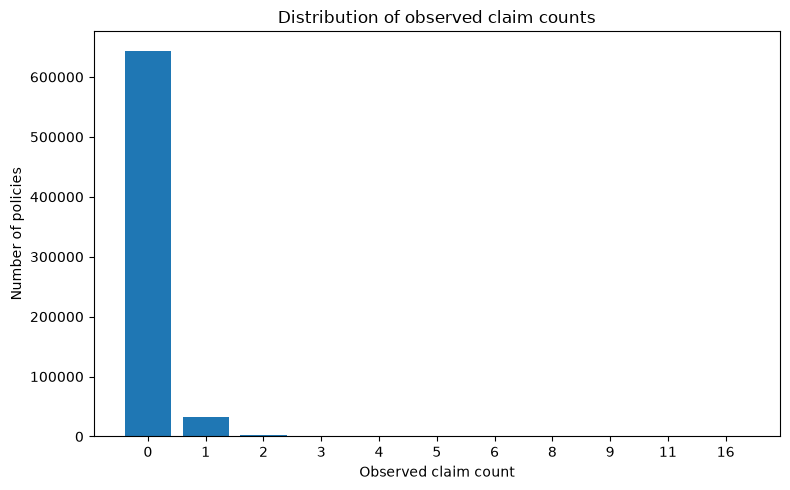

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(
    claim_count_distribution.index.astype(str),
    claim_count_distribution.values,
)
plt.xlabel("Observed claim count")
plt.ylabel("Number of policies")
plt.title("Distribution of observed claim counts")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "eda_claim_count_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [18]:
df_clean["Exposure"].describe()

count    678013.000000
mean          0.528750
std           0.364442
min           0.002732
25%           0.180000
50%           0.490000
75%           0.990000
max           2.010000
Name: Exposure, dtype: float64

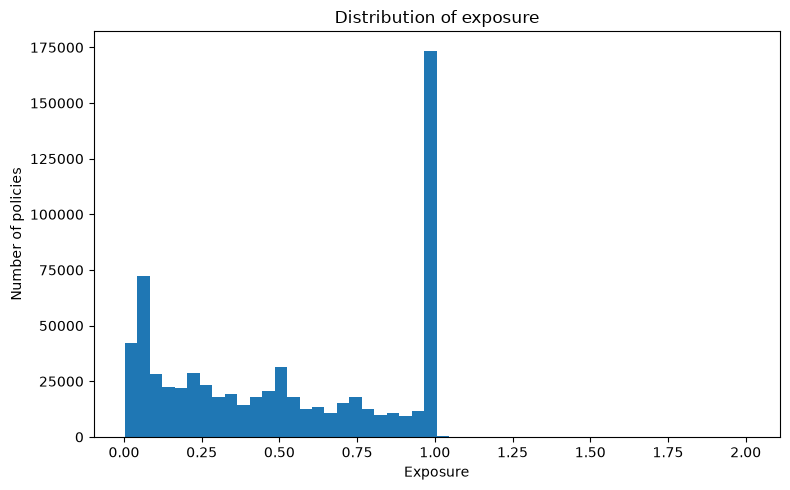

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Exposure"], bins=50)
plt.xlabel("Exposure")
plt.ylabel("Number of policies")
plt.title("Distribution of exposure")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "eda_exposure_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Observed frequency by selected risk variables

We now compute observed claim frequency by selected risk variables.

For a group \(g\), the observed annual frequency is:

\[
\frac{\sum_{i\in g} N_i}{\sum_{i\in g} E_i}.
\]

This exposure-weighted frequency is more appropriate than a simple average of individual frequencies.

In [20]:
df_eda = df_clean.copy()

df_eda["BonusMalus_decile"] = (
    pd.qcut(
        df_eda["BonusMalus"].rank(method="first"),
        q=10,
        labels=False,
    )
    + 1
)

bonusmalus_frequency = (
    df_eda.groupby("BonusMalus_decile")
    .agg(
        exposure=("Exposure", "sum"),
        observed_claims=("ClaimNb", "sum"),
        n_policies=("ClaimNb", "size"),
    )
    .reset_index()
)

bonusmalus_frequency["observed_frequency"] = (
    bonusmalus_frequency["observed_claims"]
    / bonusmalus_frequency["exposure"]
)

bonusmalus_frequency

,BonusMalus_decile,exposure,observed_claims,n_policies,observed_frequency
0,1,45226.218802,8967,67802,0.198270
1,2,45459.589315,2385,67801,0.052464
2,3,36670.055753,1958,67801,0.053395
3,4,38993.412740,1861,67801,0.047726
4,5,41794.806347,1963,67802,0.046968
5,6,29215.987336,1929,67801,0.066025
6,7,34025.884913,3428,67801,0.100747
7,8,31822.684955,4426,67801,0.139083
8,9,28657.457244,3646,67801,0.127227
9,10,26633.348057,5539,67802,0.207972


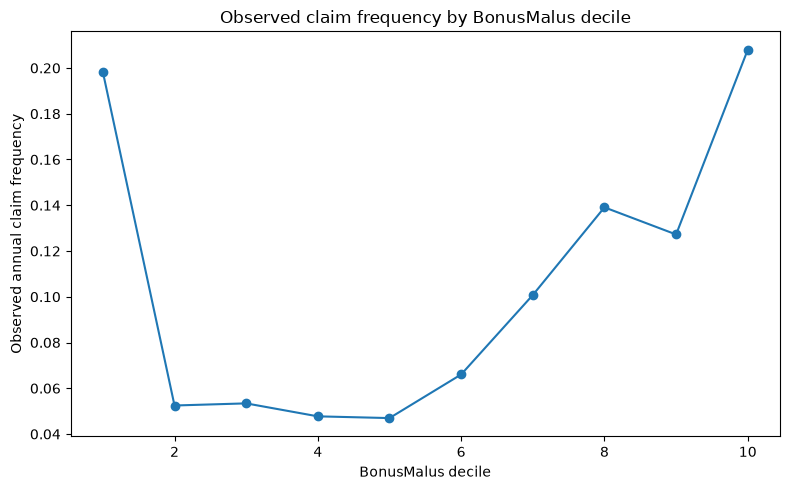

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(
    bonusmalus_frequency["BonusMalus_decile"],
    bonusmalus_frequency["observed_frequency"],
    marker="o",
)
plt.xlabel("BonusMalus decile")
plt.ylabel("Observed annual claim frequency")
plt.title("Observed claim frequency by BonusMalus decile")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "eda_frequency_by_bonusmalus_decile.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [22]:
area_frequency = (
    df_clean.groupby("Area")
    .agg(
        exposure=("Exposure", "sum"),
        observed_claims=("ClaimNb", "sum"),
        n_policies=("ClaimNb", "size"),
    )
    .reset_index()
)

area_frequency["observed_frequency"] = (
    area_frequency["observed_claims"]
    / area_frequency["exposure"]
)

area_frequency = area_frequency.sort_values("observed_frequency")

area_frequency

,Area,exposure,observed_claims,n_policies,observed_frequency
0,A,61969.377712,5063,103957,0.081702
1,B,43012.323931,3800,75459,0.088347
2,C,104449.003784,9875,191880,0.094544
3,D,77120.191692,8428,151596,0.109284
4,E,63819.314270,7805,137167,0.122298
5,F,8129.234074,1131,17954,0.139127


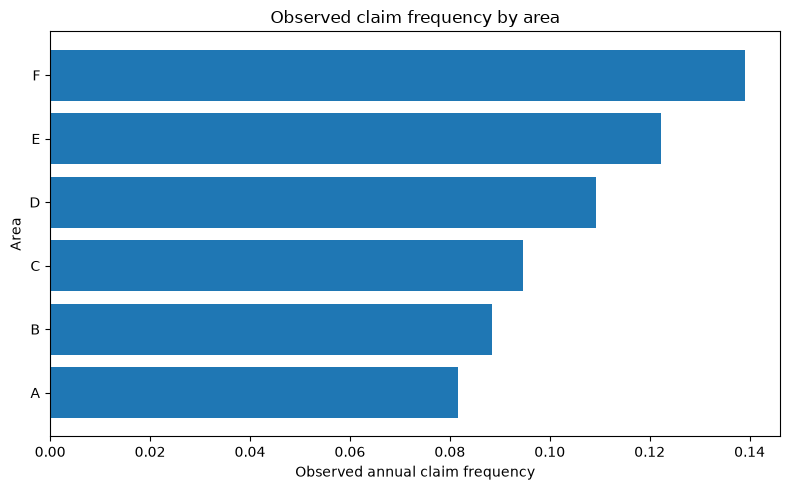

In [23]:
plt.figure(figsize=(8, 5))
plt.barh(
    area_frequency["Area"],
    area_frequency["observed_frequency"],
)
plt.xlabel("Observed annual claim frequency")
plt.ylabel("Area")
plt.title("Observed claim frequency by area")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "eda_frequency_by_area.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [26]:
vehgas_frequency = (
    df_clean.groupby("VehGas")
    .agg(
        exposure=("Exposure", "sum"),
        observed_claims=("ClaimNb", "sum"),
        n_policies=("ClaimNb", "size"),
    )
    .reset_index()
)

vehgas_frequency["observed_frequency"] = (
    vehgas_frequency["observed_claims"]
    / vehgas_frequency["exposure"]
)

vehgas_frequency = vehgas_frequency.sort_values("observed_frequency")

vehgas_frequency

,VehGas,exposure,observed_claims,n_policies,observed_frequency
0,Diesel,170660.893126,16648,332136,0.097550
1,Regular,187838.552336,19454,345877,0.103568


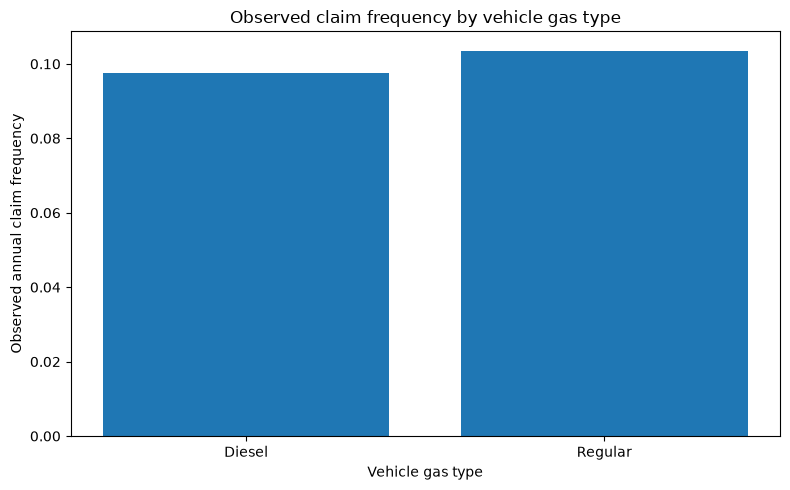

In [25]:
plt.figure(figsize=(8, 5))
plt.bar(
    vehgas_frequency["VehGas"],
    vehgas_frequency["observed_frequency"],
)
plt.xlabel("Vehicle gas type")
plt.ylabel("Observed annual claim frequency")
plt.title("Observed claim frequency by vehicle gas type")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "eda_frequency_by_vehgas.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 6. Feature columns

The explanatory variables are selected by excluding:

- the policy identifier;
- the observed claim count;
- the exposure;
- the empirical frequency target.

Exposure is not used as an ordinary feature. It is used later as sample weight in the modeling notebook.

In [27]:
feature_columns = get_feature_columns(df_clean)

feature_columns

['VehPower',
 'VehAge',
 'DrivAge',
 'BonusMalus',
 'VehBrand',
 'VehGas',
 'Area',
 'Density',
 'Region']

In [28]:
numeric_features, categorical_features = split_numeric_categorical_features(
    df_clean,
    feature_columns,
)

numeric_features, categorical_features

(['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density'],
 ['VehBrand', 'VehGas', 'Area', 'Region'])

In [29]:
feature_summary = pd.DataFrame({
    "feature": feature_columns,
    "type": [
        "numeric" if feature in numeric_features else "categorical"
        for feature in feature_columns
    ],
})

feature_summary

,feature,type
0,VehPower,numeric
1,VehAge,numeric
2,DrivAge,numeric
3,BonusMalus,numeric
4,VehBrand,categorical
5,VehGas,categorical
6,Area,categorical
7,Density,numeric
8,Region,categorical


## 7. Save processed dataset

The cleaned dataset is saved to:

```text
data/processed/frequency_clean.csv
```

In [30]:
save_processed_data(df_clean, DATA_PROCESSED_PATH)

In [31]:
DATA_PROCESSED_PATH.exists()

True

# Final conclusion of Notebook 01

The data exploration and preparation step is complete.

The raw dataset contains 678,013 observations and 12 original columns. After cleaning, the processed dataset contains 678,013 observations and 13 columns, including the empirical claim frequency target:

\[
Y_i^{freq} = \frac{N_i}{E_i}.
\]

The main actuarial data quality checks were validated:

- no missing values in `ClaimNb`;
- no missing values in `Exposure`;
- all exposures are strictly positive;
- all claim counts are non-negative.

The global observed annual claim frequency is approximately:

\[
\frac{\sum_i N_i}{\sum_i E_i} \approx 0.1007.
\]

The selected explanatory variables are:

- numerical features: `VehPower`, `VehAge`, `DrivAge`, `BonusMalus`, `Density`;
- categorical features: `VehBrand`, `VehGas`, `Area`, `Region`.

The cleaned dataset was saved to:

```text
data/processed/frequency_clean.csv
```
This processed file is used as the input for 02_modeling_glm_gb.ipynb.